In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [52]:
func_a = lambda x: 3 + 2*x
func_b = lambda x: -25 +10*x  -x**2
func_c = lambda x: 2*np.log(x)
func_d = lambda x: x**2 - 1/x

def mse(x):
    n = len(x)
    return np.linalg.norm(x)/np.sqrt(n)
def gen_data(f,*x, noise = 0.1):
    y = f(*x)
    m = mse(y)
    return y + noise*m*np.random.randn(len(y))

x = np.linspace(1,10,100)
itens = ['a', 'b', 'c', 'd']
funs = [func_a,func_b,func_c,func_d]
for i,f in zip(itens, funs):
    xi = np.random.choice(x,50,replace=False)
    y = gen_data(f,xi)
    np.savez(f'ex1_{i}.npz', x=xi, y=y)

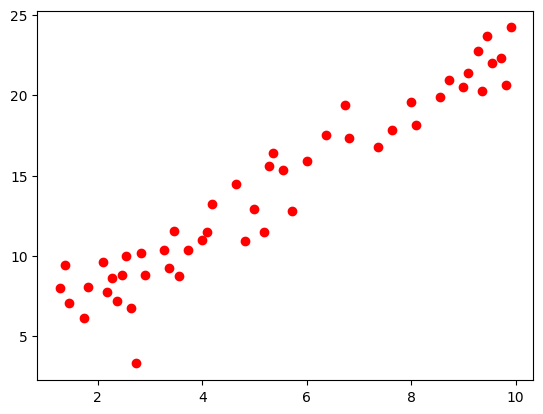

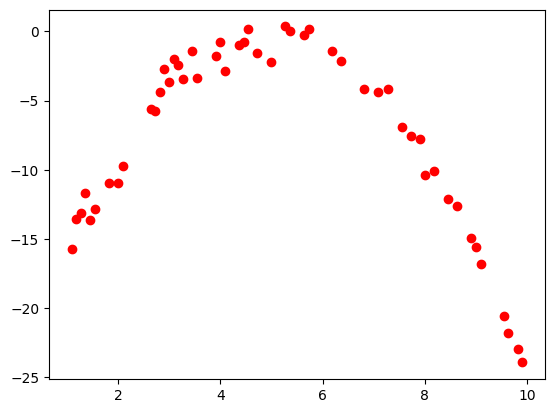

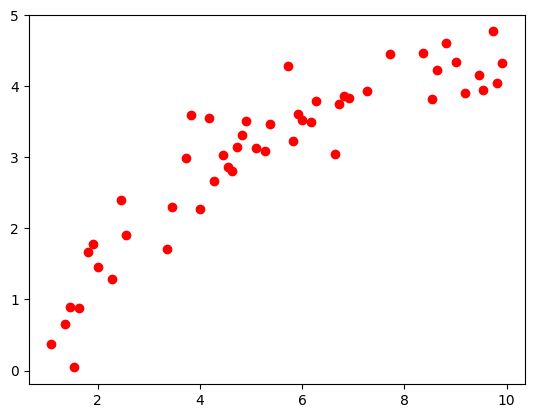

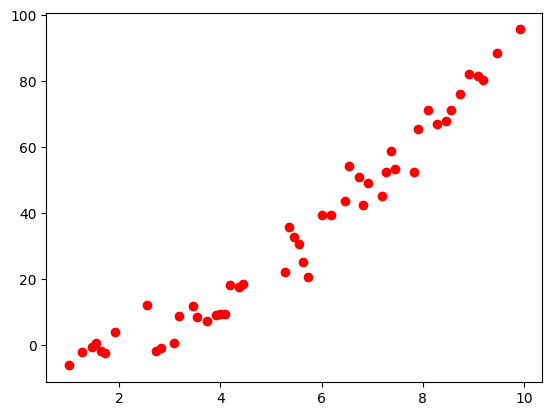

In [53]:
for i in itens:
    data = np.load(f'ex1_{i}.npz')
    x = data['x']
    y = data['y']
    plt.figure()
    plt.plot(x,y, 'ro')

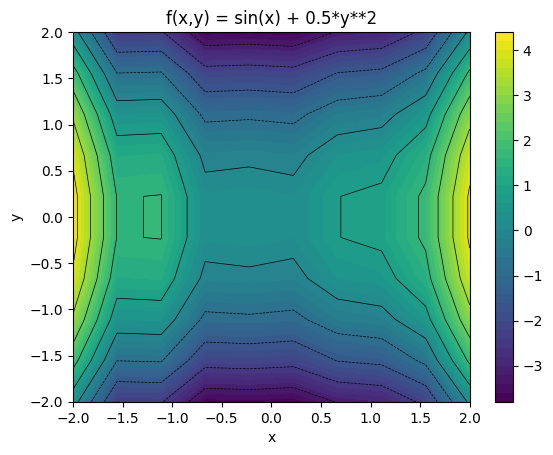

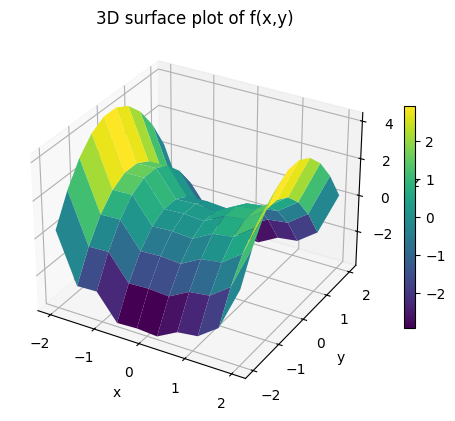

In [55]:
from mpl_toolkits.mplot3d import Axes3D

# Ex 2

# fxy = lambda x,y: np.sin(x) + 0.5*y**2
# fxy = lambda x,y: x**2 - y + 0.5*x*y
fxy = lambda x,y: x**2 - y**2

x = np.linspace(-2,2,10)
y = x.copy()

X,Y = np.meshgrid(x,y)
# z = fxy(X,Y)
z = gen_data(fxy,X,Y, noise=0.05)

plt.figure()
cf = plt.contourf(X, Y, z, levels=50, cmap='viridis')
plt.contour(X, Y, z, levels=10, colors='k', linewidths=0.5)
plt.colorbar(cf)
plt.xlabel('x')
plt.ylabel('y')
plt.title('f(x,y) = sin(x) + 0.5*y**2')
plt.show()

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
surf = ax.plot_surface(X, Y, z, cmap='viridis', edgecolor='none', antialiased=True)
fig.colorbar(surf, ax=ax, shrink=0.6)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('3D surface plot of f(x,y)')
plt.show()

In [63]:
# ex 3

dados = [[1971, 2250],
[1972, 2500],
[1974, 5000],
[1978, 29000],
[1982, 120000],
[1985, 275000],
[1989, 1180000],
[1993, 3100000],
[1997, 7500000],
[1999, 24000000],
[2000, 42000000],
[2002, 220000000],
[2003, 410000000]]

dados = np.array(dados)
ano = dados[:,0]
transistors = dados[:,1]

np.savez_compressed('ex3.npz', ano = ano, transistors=transistors)

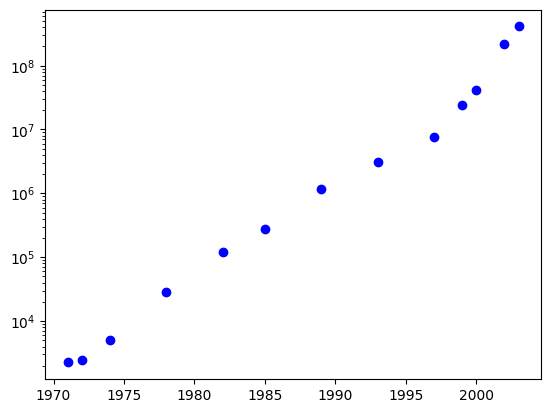

In [10]:
dados_ex1 = np.load('ex_1.npz')

ano = dados_ex1['ano']
transistors = dados_ex1['transistors']
plt.plot(ano, transistors, 'bo')
plt.yscale('log')

In [62]:
dados_batery = [
[12,24.7,99.72],
[25,25.3,99.23],
[37,24.9,98.88],
[50,26.1,98.44],
[63,24.4,98.01],
[75,27.0,97.45],
[88,25.6,96.94],
[101,26.4,96.37],
[115,24.8,95.93],
[128,25.5,95.26],
[140,27.2,94.84],
[155,23.9,94.37],
[169,25.1,93.71],
[182,26.7,93.15],
[195,24.3,92.54],
[210,27.6,91.83],
[225,25.4,91.12],
[240,26.1,90.34],
[255,24.5,89.66],
[270,27.8,88.85],
[285,25.2,88.21],
[300,26.9,87.43],
[315,28.0,86.51],
[330,25.8,85.86],
[345,24.6,85.12],
[360,26.3,84.32],
[375,27.5,83.48],
[390,25.0,82.91],
[405,28.1,82.02],
[420,26.6,81.21],
[435,24.7,80.55],
[450,27.3,79.62],
[465,25.5,78.94],
[480,28.4,78.02],
[495,26.0,77.21],
[510,24.9,76.48],
[525,27.8,75.52],
[540,26.2,74.74],
[555,25.1,73.96],
[570,28.3,73.07],
[585,27.0,72.34],
[600,24.8,71.62],
[620,27.4,70.51],
[640,26.5,69.31],
[660,28.1,68.05],
[680,25.3,67.14],
[700,27.6,66.02],
[720,26.0,65.01],
[740,28.7,63.73],
[760,27.5,62.68],
[780,25.9,61.64],
[800,29.0,60.32],
[820,27.1,59.33],
[840,26.4,58.22],
[860,28.9,56.91],
[880,27.3,55.83],
[900,25.8,54.81],
[920,29.2,53.54],
[940,27.6,52.46],
[960,26.3,51.41],
[980,28.8,50.09],
[1000,27.0,49.01],
[1020,25.5,48.06],
[1040,29.3,46.74],
[1060,27.2,45.69],
[1080,26.0,44.55],
[1100,29.4,43.26],
[1120,27.8,42.11],
[1140,25.9,41.18],
[1160,29.5,39.93],
[1180,27.5,38.87],
[1200,26.1,37.82],
[1220,29.7,36.51],
[1240,27.9,35.44],
[1260,25.8,34.58],
[1280,29.9,33.12],
[1300,28.0,32.15],
[1320,26.3,31.02],
[1340,30.1,29.71],
[1360,27.6,28.62],
[1380,25.7,27.81],
[1400,30.2,26.34],
[1420,28.1,25.31],
[1440,26.2,24.19],
[1460,30.4,22.93],
[1480,27.7,21.84],
[1500,26.0,20.79],
[1520,30.5,19.41],
[1540,28.0,18.39],
[1560,26.4,17.35],
[1580,30.7,16.04],
[1600,27.9,15.02],
[1620,26.5,14.01],
[1640,30.9,12.65],
[1660,28.2,11.59],
[1680,26.7,10.58],
[1700,31.0,9.19],
]

dados_batery =np.array(dados_batery)
dados_batery.shape

n = dados_batery[:,0]
T = dados_batery[:,1]
C = lambda n,t: 100 - 0.015*n - 0.12*(t-25) - 3e-6*n**2 + np.random.randn()
C = np.vectorize(C)

cap = C(n,T)

np.savez('ex4.npz', cycle=n, temperature=T, capacity=cap)

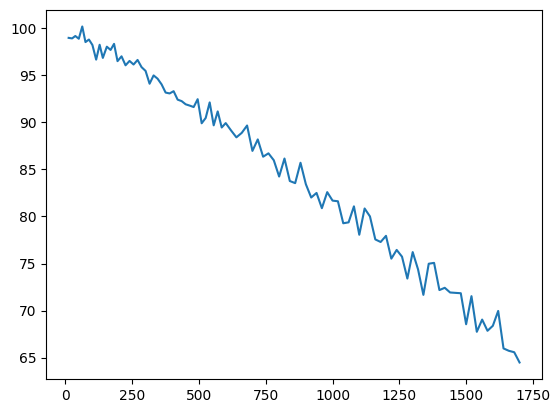

In [61]:
plt.plot(n, cap)